**Fake News Detection Dataset**

**Problem Statement:** The rapid spread of fake news on digital platforms makes it difficult for users to identify trustworthy information. This project aims to build a machine learning-based Fake News Detection system that analyzes the text of news articles and classifies them as Fake or Real using Natural Language Processing (NLP) techniques. The solution helps automate news verification and supports informed decision-making.

**Objective:** To develop a machine learning-based Fake News Detection system that accurately classifies news articles as Fake or Real using Natural Language Processing (NLP) techniques. The project aims to evaluate multiple classification algorithms and deploy the best-performing model for real-time news detection.

**Business Objective:**

To develop an automated system that helps identify fake news articles quickly and accurately, reducing the spread of misinformation. The solution can assist media organizations, social media platforms and users in verifying the authenticity of news content and supporting informed decision-making.

**Dataset:** Fake News Detection

**Source:** Kaggle

**Step 0** - Importing Libraries :

In [73]:
# Data Manipulation
import pandas as pd
import numpy as np

# Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

# Text Processing
import re
import string
import nltk

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
from nltk.stem import PorterStemmer

# Download NLTK Resources
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

# Feature Extraction
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

# Train-Test Split
from sklearn.model_selection import train_test_split

# Machine Learning Algorithms
from sklearn.naive_bayes import MultinomialNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier

# Hyperparameter Tuning
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV

# Model Evaluation
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    roc_auc_score
)

# Label Encoding
from sklearn.preprocessing import LabelEncoder

# Model Saving & Loading
import joblib

# Ignore Warnings
import warnings
warnings.filterwarnings('ignore')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


**Step 1:** Importing Data


In [74]:
# Read Dataset
df = pd.read_csv("/content/fake_or_real_news.csv")


In [75]:
# Display first 5 rows
print("First 5 Records:")
display(df.head())

First 5 Records:


,Unnamed: 0,title,text,label
0,8476,You Can Smell Hillary’s Fear,"Daniel Greenfield, a Shillman Journalism Fello...",FAKE
1,10294,Watch The Exact Moment Paul Ryan Committed Pol...,Google Pinterest Digg Linkedin Reddit Stumbleu...,FAKE
2,3608,Kerry to go to Paris in gesture of sympathy,U.S. Secretary of State John F. Kerry said Mon...,REAL
3,10142,Bernie supporters on Twitter erupt in anger ag...,"— Kaydee King (@KaydeeKing) November 9, 2016 T...",FAKE
4,875,The Battle of New York: Why This Primary Matters,It's primary day in New York and front-runners...,REAL


In [76]:
# Drop Unnamed column
df = df.loc[:, ~df.columns.str.contains("^Unnamed")]

In [77]:
# Rename target column from 'label' to 'labels'
df.rename(columns={"label": "labels"}, inplace=True)

In [78]:
# Display Dataset Shape
print("Dataset Shape:", df.shape)

Dataset Shape: (6335, 3)


In [79]:
# Display First 5 rows
print("First 5 Records:")
display(df.head())

First 5 Records:


,title,text,labels
0,You Can Smell Hillary’s Fear,"Daniel Greenfield, a Shillman Journalism Fello...",FAKE
1,Watch The Exact Moment Paul Ryan Committed Pol...,Google Pinterest Digg Linkedin Reddit Stumbleu...,FAKE
2,Kerry to go to Paris in gesture of sympathy,U.S. Secretary of State John F. Kerry said Mon...,REAL
3,Bernie supporters on Twitter erupt in anger ag...,"— Kaydee King (@KaydeeKing) November 9, 2016 T...",FAKE
4,The Battle of New York: Why This Primary Matters,It's primary day in New York and front-runners...,REAL


In [80]:
# Display Last 5 Rows
print("Last 5 Records:")
display(df.tail())

Last 5 Records:


,title,text,labels
6330,State Department says it can't find emails fro...,The State Department told the Republican Natio...,REAL
6331,The ‘P’ in PBS Should Stand for ‘Plutocratic’ ...,The ‘P’ in PBS Should Stand for ‘Plutocratic’ ...,FAKE
6332,Anti-Trump Protesters Are Tools of the Oligarc...,Anti-Trump Protesters Are Tools of the Oligar...,FAKE
6333,"In Ethiopia, Obama seeks progress on peace, se...","ADDIS ABABA, Ethiopia —President Obama convene...",REAL
6334,Jeb Bush Is Suddenly Attacking Trump. Here's W...,Jeb Bush Is Suddenly Attacking Trump. Here's W...,REAL


In [81]:
# Check Data Types
print("Data Types:")
print(df.dtypes)


Data Types:
title     object
text      object
labels    object
dtype: object


In [82]:
# Display Column Names
print("Columns in Dataset:")
print(df.columns.tolist())

Columns in Dataset:
['title', 'text', 'labels']


In [83]:
# Identify Text and Target Columns
text_column = "text"
target_column = "labels"

print("Text Column :", text_column)
print("Target Column :", target_column)

Text Column : text
Target Column : labels


**Step 2: Dataset Exploration (EDA)**


**Dataset Information**

In [84]:
# Dataset Shape
print("Dataset Shape:")
print(df.shape)


Dataset Shape:
(6335, 3)


In [85]:
# Number of Rows and Columns
print("Number of Rows :", df.shape[0])
print("Number of Columns :", df.shape[1])


Number of Rows : 6335
Number of Columns : 3


In [86]:
# Column Names
print("Column Names:")
print(df.columns.tolist())

Column Names:
['title', 'text', 'labels']


In [87]:
# Data Types
print("Data Types:")
print(df.dtypes)

Data Types:
title     object
text      object
labels    object
dtype: object


In [89]:
# Dataset Information
print("Dataset Information:")
df.info()

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6335 entries, 0 to 6334
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   title   6335 non-null   object
 1   text    6335 non-null   object
 2   labels  6335 non-null   object
dtypes: object(3)
memory usage: 148.6+ KB


In [90]:
# Missing Values
print("Missing Values:")
print(df.isnull().sum())

Missing Values:
title     0
text      0
labels    0
dtype: int64


In [91]:
# Duplicate Records
print("Duplicate Records:", df.duplicated().sum())

Duplicate Records: 29


In [92]:
# Remove Duplicate Records
df.drop_duplicates(inplace=True)

In [93]:
# Verify duplicates are removed
print("Duplicate Records after removal:", df.duplicated().sum())

Duplicate Records after removal: 0


**Target Variable Analysis**


In [94]:
#Class Distribution
# Count of each class
class_counts = df["labels"].value_counts()

print("Class Distribution:")
print(class_counts)

Class Distribution:
labels
REAL    3154
FAKE    3152
Name: count, dtype: int64


In [95]:
# Percentage of each class
class_percentage = df["labels"].value_counts(normalize=True) * 100

print("Percentage of Each Class:")
print(class_percentage.round(2))

Percentage of Each Class:
labels
REAL    50.02
FAKE    49.98
Name: proportion, dtype: float64


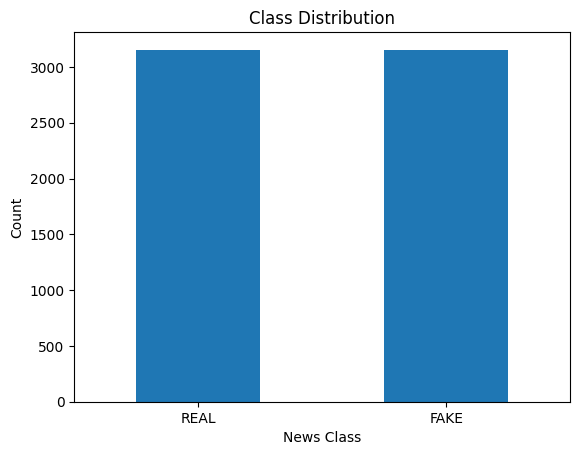

In [97]:
import matplotlib.pyplot as plt

# Count Plot
df["labels"].value_counts().plot(kind="bar")

plt.title("Class Distribution")
plt.xlabel("News Class")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.show()

**Text Analysis**

In [98]:
# Character Count
df["Character_Count"] = df["text"].apply(len)

print(df["Character_Count"].head())

0    7518
1    2646
2    2543
3    2660
4    1840
Name: Character_Count, dtype: int64


In [99]:
# Word Count
df["Word_Count"] = df["text"].apply(lambda x: len(str(x).split()))

print(df["Word_Count"].head())

0    1296
1     446
2     431
3     404
4     317
Name: Word_Count, dtype: int64


In [100]:
# Sentence Count
df["Sentence_Count"] = df["text"].apply(
    lambda x: len([s for s in str(x).split('.') if s.strip() != ""])
)

print(df["Sentence_Count"].head())

0    85
1    28
2    25
3    18
4    21
Name: Sentence_Count, dtype: int64


In [101]:
# Average Word Length
df["Average_Word_Length"] = df["text"].apply(
    lambda x: sum(len(word) for word in str(x).split()) / len(str(x).split())
    if len(str(x).split()) > 0 else 0
)

print(df["Average_Word_Length"].head())

0    4.776235
1    4.917040
2    4.883991
3    5.554455
4    4.776025
Name: Average_Word_Length, dtype: float64


In [102]:
# Vocabulary Size
vocabulary = set()

for text in df["text"]:
    vocabulary.update(str(text).lower().split())

print("Vocabulary Size:", len(vocabulary))

Vocabulary Size: 193753


In [103]:
df[[
    "Character_Count",
    "Word_Count",
    "Sentence_Count",
    "Average_Word_Length"
]].head()

,Character_Count,Word_Count,Sentence_Count,Average_Word_Length
0,7518,1296,85,4.776235
1,2646,446,28,4.917040
2,2543,431,25,4.883991
3,2660,404,18,5.554455
4,1840,317,21,4.776025


**Visual Analysis**

**Univariate Analysis**

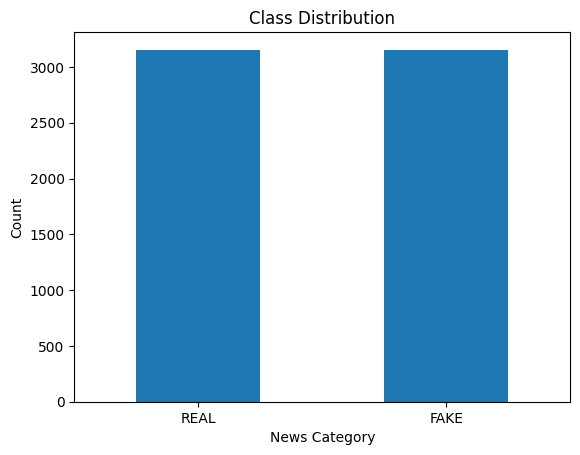

In [104]:
#Count Plot
import matplotlib.pyplot as plt

# Count Plot
df["labels"].value_counts().plot(kind="bar")

plt.title("Class Distribution")
plt.xlabel("News Category")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.show()

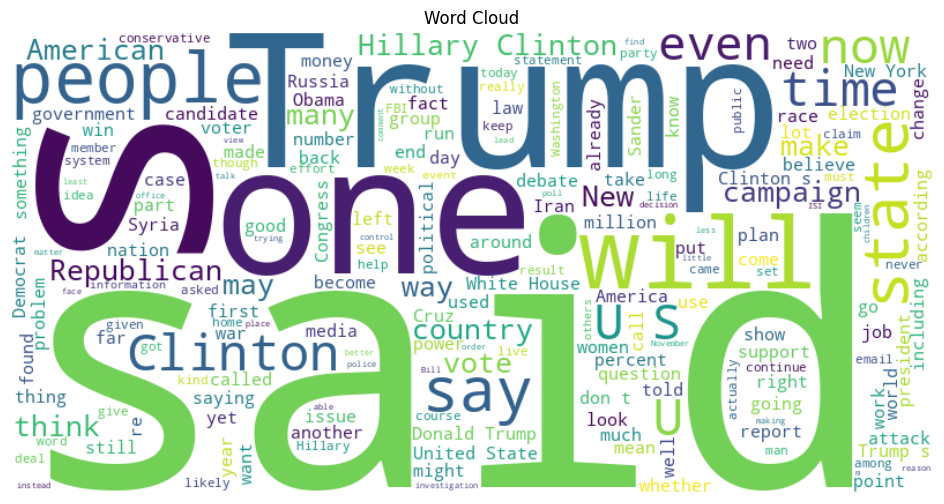

In [105]:
#Word Cloud
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Combine all news text
text = " ".join(df["text"].astype(str))

# Generate Word Cloud
wordcloud = WordCloud(
    width=800,
    height=400,
    background_color="white"
).generate(text)

# Display
plt.figure(figsize=(12,6))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Word Cloud")
plt.show()

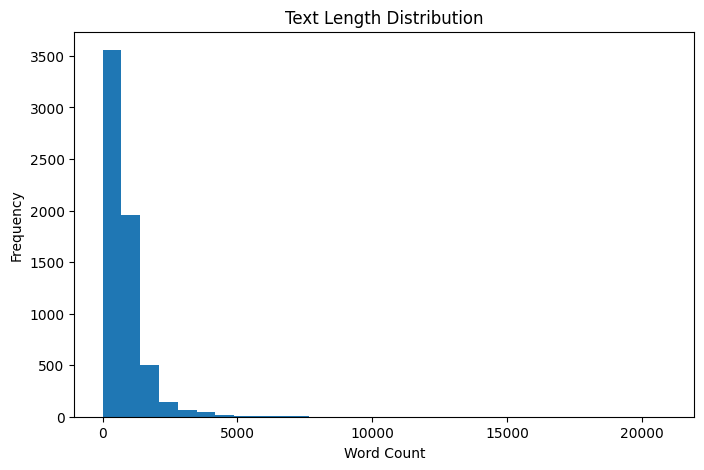

In [106]:
#Text Length Distribution
#Using the Word_Count feature
plt.figure(figsize=(8,5))

plt.hist(df["Word_Count"], bins=30)

plt.title("Text Length Distribution")
plt.xlabel("Word Count")
plt.ylabel("Frequency")

plt.show()

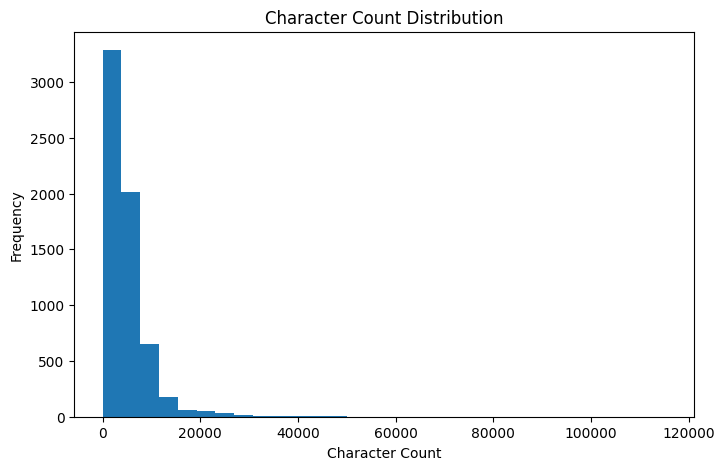

In [107]:
#using Character_Count
plt.figure(figsize=(8,5))

plt.hist(df["Character_Count"], bins=30)

plt.title("Character Count Distribution")
plt.xlabel("Character Count")
plt.ylabel("Frequency")

plt.show()

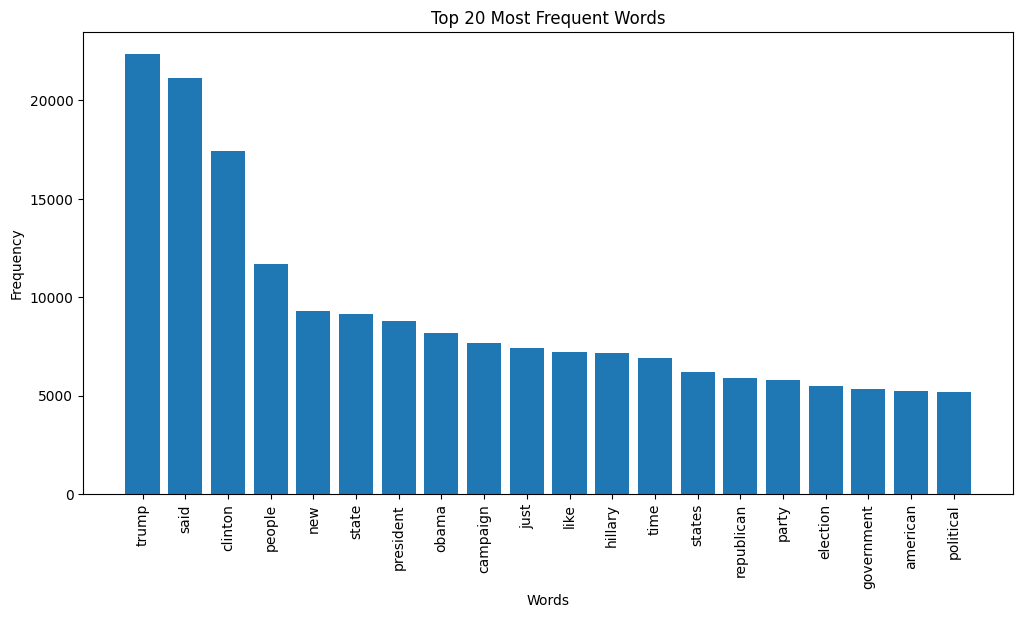

In [108]:
#Word Frequency Plot
from sklearn.feature_extraction.text import CountVectorizer

# Create CountVectorizer
vectorizer = CountVectorizer(stop_words="english")

X = vectorizer.fit_transform(df["text"])

# Sum word frequencies
word_freq = X.toarray().sum(axis=0)

# Create DataFrame
freq_df = (
    pd.DataFrame({
        "Word": vectorizer.get_feature_names_out(),
        "Frequency": word_freq
    })
    .sort_values(by="Frequency", ascending=False)
    .head(20)
)

# Plot
plt.figure(figsize=(12,6))

plt.bar(freq_df["Word"], freq_df["Frequency"])

plt.title("Top 20 Most Frequent Words")
plt.xlabel("Words")
plt.ylabel("Frequency")

plt.xticks(rotation=90)

plt.show()

**Bivariate Analysis**

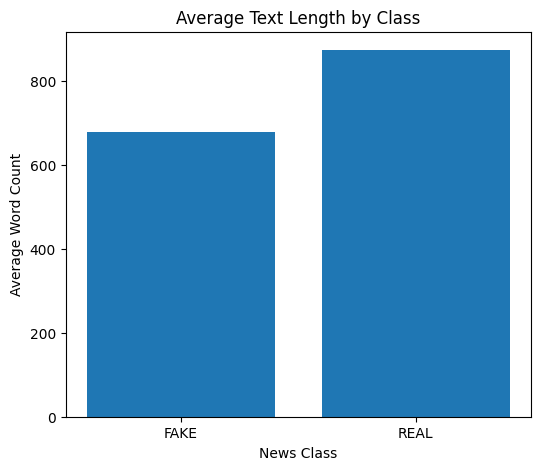

In [109]:
#Average Text Length by Class
#Using Word Count
import matplotlib.pyplot as plt

# Calculate average word count for each class
avg_length = df.groupby("labels")["Word_Count"].mean()

# Plot
plt.figure(figsize=(6,5))

plt.bar(avg_length.index, avg_length.values)

plt.title("Average Text Length by Class")
plt.xlabel("News Class")
plt.ylabel("Average Word Count")

plt.show()

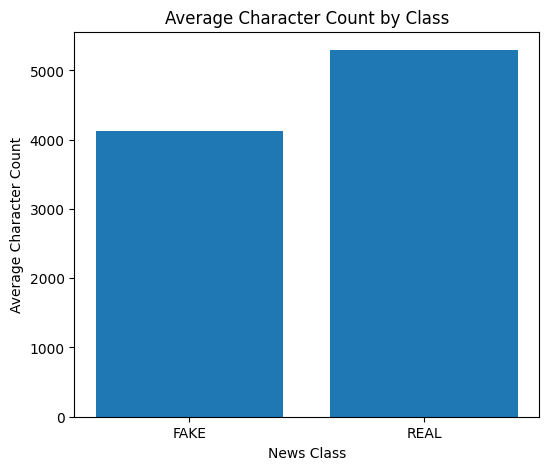

In [110]:
#Using Character_Count
avg_char = df.groupby("labels")["Character_Count"].mean()

plt.figure(figsize=(6,5))

plt.bar(avg_char.index, avg_char.values)

plt.title("Average Character Count by Class")
plt.xlabel("News Class")
plt.ylabel("Average Character Count")

plt.show()

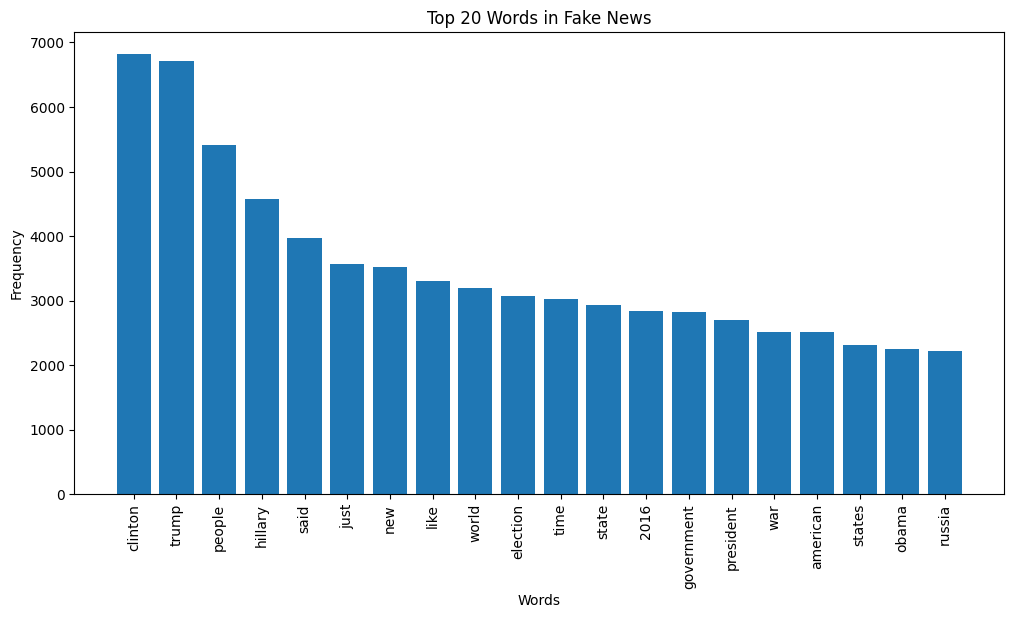

In [111]:
#Top Words in Each Class
#Top 20 Words in Fake News

from sklearn.feature_extraction.text import CountVectorizer
import pandas as pd
import matplotlib.pyplot as plt

# Fake News
fake_text = " ".join(df[df["labels"] == "FAKE"]["text"].astype(str))

vectorizer = CountVectorizer(stop_words="english")

X = vectorizer.fit_transform([fake_text])

word_freq = X.toarray().sum(axis=0)

fake_words = pd.DataFrame({
    "Word": vectorizer.get_feature_names_out(),
    "Frequency": word_freq
})

fake_words = fake_words.sort_values(by="Frequency", ascending=False).head(20)

plt.figure(figsize=(12,6))

plt.bar(fake_words["Word"], fake_words["Frequency"])

plt.title("Top 20 Words in Fake News")
plt.xlabel("Words")
plt.ylabel("Frequency")

plt.xticks(rotation=90)

plt.show()

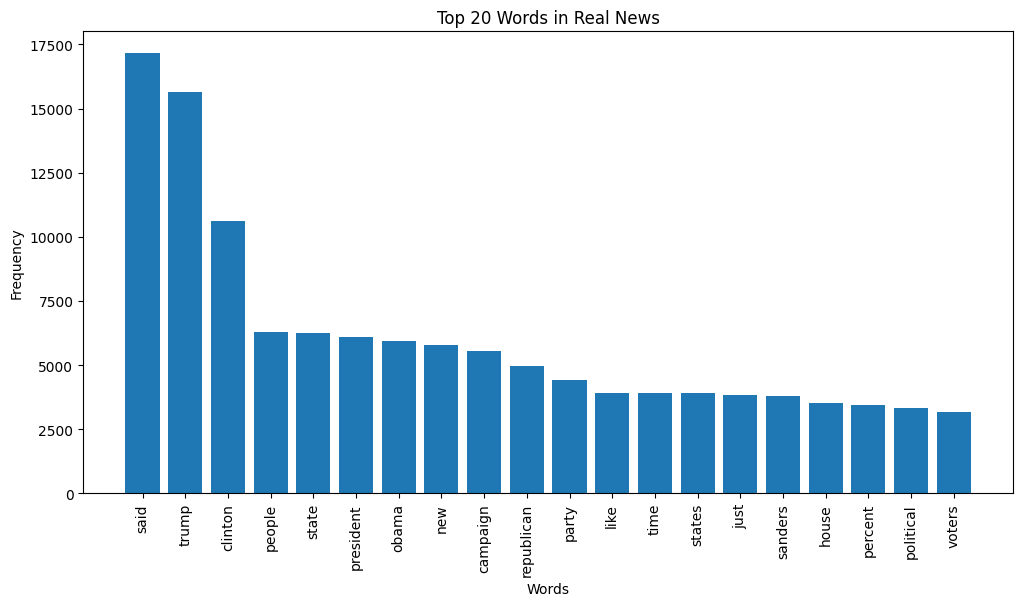

In [112]:
#Top 20 Words in Real News
# Real News
real_text = " ".join(df[df["labels"] == "REAL"]["text"].astype(str))

vectorizer = CountVectorizer(stop_words="english")

X = vectorizer.fit_transform([real_text])

word_freq = X.toarray().sum(axis=0)

real_words = pd.DataFrame({
    "Word": vectorizer.get_feature_names_out(),
    "Frequency": word_freq
})

real_words = real_words.sort_values(by="Frequency", ascending=False).head(20)

plt.figure(figsize=(12,6))

plt.bar(real_words["Word"], real_words["Frequency"])

plt.title("Top 20 Words in Real News")
plt.xlabel("Words")
plt.ylabel("Frequency")

plt.xticks(rotation=90)

plt.show()

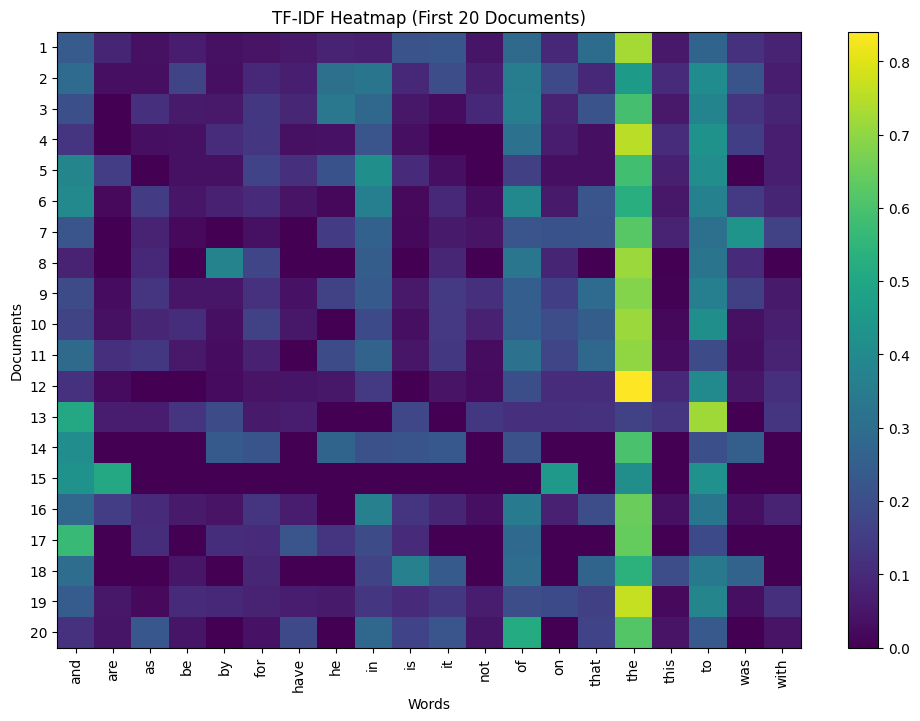

In [113]:
#Multivariate Analysis
#TF-IDF Heatmap
from sklearn.feature_extraction.text import TfidfVectorizer
import matplotlib.pyplot as plt

# TF-IDF Vectorizer
tfidf = TfidfVectorizer(max_features=20)

X_tfidf = tfidf.fit_transform(df["text"])

# Convert to DataFrame
tfidf_df = pd.DataFrame(
    X_tfidf.toarray(),
    columns=tfidf.get_feature_names_out()
)

# Plot Heatmap
plt.figure(figsize=(12,8))

plt.imshow(tfidf_df.head(20), aspect='auto')

plt.colorbar()

plt.xticks(
    range(len(tfidf_df.columns)),
    tfidf_df.columns,
    rotation=90
)

plt.yticks(range(20), range(1,21))

plt.title("TF-IDF Heatmap (First 20 Documents)")
plt.xlabel("Words")
plt.ylabel("Documents")

plt.show()

This heatmap shows the TF-IDF values for the most important words.

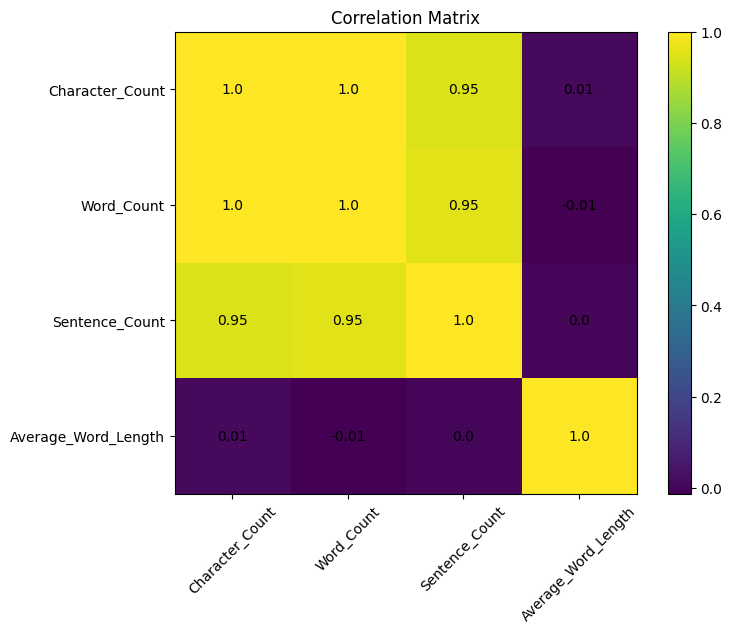

In [114]:
#Correlation Matrix (Engineered Numerical Features)
import matplotlib.pyplot as plt

# Select numerical features
features = [
    "Character_Count",
    "Word_Count",
    "Sentence_Count",
    "Average_Word_Length"
]

# Correlation Matrix
corr_matrix = df[features].corr()

plt.figure(figsize=(8,6))

plt.imshow(corr_matrix)

plt.colorbar()

plt.xticks(range(len(features)), features, rotation=45)
plt.yticks(range(len(features)), features)

plt.title("Correlation Matrix")

# Display correlation values
for i in range(len(features)):
    for j in range(len(features)):
        plt.text(
            j,
            i,
            round(corr_matrix.iloc[i, j], 2),
            ha="center",
            va="center"
        )

plt.show()

#**1. Univariate Analysis**

**Observations:**

* The dataset contains two target classes: FAKE and REAL news.

* The class distribution is nearly balanced, indicating similar numbers of fake and real news articles.

* The Word Cloud highlights the most frequently occurring words across all news articles.

* News articles vary in length, with most containing a moderate number of words and characters.

* The Word Frequency Plot shows that certain words occur much more frequently than others.

**Insights:**

* Since the classes are balanced, special techniques for handling class imbalance may not be required.

* Frequently occurring words alone may not be sufficient for classification because they appear in both classes.

* Article length varies across the dataset, which may influence model learning.

**Recommendations:**

* Apply text preprocessing such as stopword removal and lemmatization to improve text quality.

* Use TF-IDF Vectorization instead of raw word frequencies to capture the importance of words.

* Retain text length features as additional engineered features for further analysis.

#**2. Bivariate Analysis**

**Observations:**

* The average text length differs between Fake and Real news articles.

* The most frequent words in Fake news differ from those in Real news.

* Some words are unique or more dominant within a specific class.

**Insights:**

* Text length may provide useful information for distinguishing between Fake and Real news.

* Differences in vocabulary indicate that word usage patterns can help classification models.

* Feature extraction techniques such as TF-IDF can effectively capture these differences.

**Recommendations:**

* Include text length features (Word Count and Character Count) during feature engineering.

* Use TF-IDF Vectorization to emphasize important words within each class.

* Evaluate multiple machine learning models to determine which best captures these textual differences.

#**3. Multivariate Analysis**

**Observations:**

* Character Count, Word Count, and Sentence Count show a positive correlation.

* Average Word Length has a weaker correlation with the other engineered features.

* The TF-IDF Heatmap highlights important words with higher weights across different documents.

**Insights:**

* Longer articles generally contain more words and sentences, indicating strong relationships among these features.

* TF-IDF effectively identifies informative words by reducing the influence of commonly occurring terms.

* Combining numerical features with TF-IDF features may improve model performance.

**Recommendations:**

* Use engineered numerical features for analysis and interpretation.

* Apply TF-IDF as the primary text vectorization technique for model training.

* Perform feature selection and hyperparameter tuning to optimize classification performance.

#**Step 3: Feature Engineering**

Create additional numerical features from the text.

Feature Engineering Techniques

Character Count

created Character Count, Word Count, Sentence Count, and Average Word Length in Step (Text Analysis), do not want to create them again. Reusing those columns and only adding the remaining features.

In [115]:
#  Feature Engineering


import string
from nltk.corpus import stopwords

# Stopwords
stop_words = set(stopwords.words("english"))

# 1. Character Count (Already Created)
df["Character_Count"] = df["text"].apply(len)

# 2. Word Count (Already Created)
df["Word_Count"] = df["text"].apply(lambda x: len(str(x).split()))

# 3. Sentence Count (Already Created)
df["Sentence_Count"] = df["text"].apply(
    lambda x: len([s for s in str(x).split('.') if s.strip() != ""])
)

# 4. Average Word Length (Already Created)
df["Average_Word_Length"] = df["text"].apply(
    lambda x: sum(len(word) for word in str(x).split()) / len(str(x).split())
    if len(str(x).split()) > 0 else 0
)

# 5. Number of Stopwords
df["Stopword_Count"] = df["text"].apply(
    lambda x: len([word for word in str(x).lower().split() if word in stop_words])
)

# 6. Number of Punctuation Marks
df["Punctuation_Count"] = df["text"].apply(
    lambda x: sum(1 for char in str(x) if char in string.punctuation)
)

# 7. Number of Digits
df["Digit_Count"] = df["text"].apply(
    lambda x: sum(char.isdigit() for char in str(x))
)

# 8. Number of Capital Letters
df["Capital_Letter_Count"] = df["text"].apply(
    lambda x: sum(char.isupper() for char in str(x))
)

# Display engineered features
df[[
    "Character_Count",
    "Word_Count",
    "Sentence_Count",
    "Average_Word_Length",
    "Stopword_Count",
    "Punctuation_Count",
    "Digit_Count",
    "Capital_Letter_Count"
]].head()

,Character_Count,Word_Count,Sentence_Count,Average_Word_Length,Stopword_Count,Punctuation_Count,Digit_Count,Capital_Letter_Count
0,7518,1296,85,4.776235,592,107,2,314
1,2646,446,28,4.917040,191,63,21,96
2,2543,431,25,4.883991,183,43,4,96
3,2660,404,18,5.554455,140,80,60,139
4,1840,317,21,4.776025,133,65,8,77


In [116]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 6306 entries, 0 to 6334
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   title                 6306 non-null   object 
 1   text                  6306 non-null   object 
 2   labels                6306 non-null   object 
 3   Character_Count       6306 non-null   int64  
 4   Word_Count            6306 non-null   int64  
 5   Sentence_Count        6306 non-null   int64  
 6   Average_Word_Length   6306 non-null   float64
 7   Stopword_Count        6306 non-null   int64  
 8   Punctuation_Count     6306 non-null   int64  
 9   Digit_Count           6306 non-null   int64  
 10  Capital_Letter_Count  6306 non-null   int64  
dtypes: float64(1), int64(7), object(3)
memory usage: 591.2+ KB


In [117]:
df.head()

,title,text,labels,Character_Count,Word_Count,Sentence_Count,Average_Word_Length,Stopword_Count,Punctuation_Count,Digit_Count,Capital_Letter_Count
0,You Can Smell Hillary’s Fear,"Daniel Greenfield, a Shillman Journalism Fello...",FAKE,7518,1296,85,4.776235,592,107,2,314
1,Watch The Exact Moment Paul Ryan Committed Pol...,Google Pinterest Digg Linkedin Reddit Stumbleu...,FAKE,2646,446,28,4.917040,191,63,21,96
2,Kerry to go to Paris in gesture of sympathy,U.S. Secretary of State John F. Kerry said Mon...,REAL,2543,431,25,4.883991,183,43,4,96
3,Bernie supporters on Twitter erupt in anger ag...,"— Kaydee King (@KaydeeKing) November 9, 2016 T...",FAKE,2660,404,18,5.554455,140,80,60,139
4,The Battle of New York: Why This Primary Matters,It's primary day in New York and front-runners...,REAL,1840,317,21,4.776025,133,65,8,77


**Observations:**

* The dataset now includes additional numerical features such as Character Count, Word Count, Sentence Count, Average Word Length, Stopword Count, Punctuation Count, Digit Count and Capital Letter Count.

* News articles vary in length and writing style, resulting in differences across these engineered features.

* Some articles contain more punctuation, digits or capital letters than others, indicating variations in formatting and content.

**Insights:**

* Text length features (Character Count, Word Count and Sentence Count) provide useful information about the structure of news articles.

* Stopword Count and Average Word Length help describe the linguistic characteristics of the text.

* Punctuation, digits and capital letters may contribute additional information that can assist in distinguishing between Fake and Real news.

**Recommendations:**

* Use TF-IDF Vectorization as the primary feature representation for model training, as it effectively captures the importance of words.

* Retain the engineered numerical features for exploratory analysis and consider combining them with TF-IDF features if they improve model performance.

* Compare multiple machine learning algorithms and perform hyperparameter tuning to identify the best-performing model.

#**Step 4: Input-Output Separation**


In [118]:
#Text Column: text
#Target Column: labels


# Input Feature (Text Column)
X = df["text"]

# Output Target Variable
y = df["labels"]

# Display Shapes
print("Input Shape (X):", X.shape)
print("Output Shape (y):", y.shape)

# Display First 5 Input Records
print("First 5 Input Records:")
display(X.head())

# Display First 5 Target Records
print("First 5 Target Records:")
display(y.head())

Input Shape (X): (6306,)
Output Shape (y): (6306,)
First 5 Input Records:


,text
0,"Daniel Greenfield, a Shillman Journalism Fello..."
1,Google Pinterest Digg Linkedin Reddit Stumbleu...
2,U.S. Secretary of State John F. Kerry said Mon...
3,"— Kaydee King (@KaydeeKing) November 9, 2016 T..."
4,It's primary day in New York and front-runners...


First 5 Target Records:


,labels
0,FAKE
1,FAKE
2,REAL
3,FAKE
4,REAL


#**Step 5: Train-Test Split**

In [119]:
from sklearn.model_selection import train_test_split

# Split the dataset into Training (80%) and Testing (20%)
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# Display Shapes
print("Training Input Shape :", X_train.shape)
print("Testing Input Shape  :", X_test.shape)
print("Training Output Shape:", y_train.shape)
print("Testing Output Shape :", y_test.shape)

Training Input Shape : (5044,)
Testing Input Shape  : (1262,)
Training Output Shape: (5044,)
Testing Output Shape : (1262,)


In [120]:
# Display first 5 training samples
print("Training Data:")
display(X_train.head())

print("Training Labels:")
display(y_train.head())

Training Data:


,text
2989,"\nIn today’s, 25th, Wikileaks release of hacke..."
5651,"Just three debates in, the saga over the CNBC ..."
3770,"Killing Obama administration rules, dismantlin..."
1931,Wikileaks Just Released Her Full Isis Donor Li...
4790,One of the big successes in US policing over t...


Training Labels:


,labels
2989,FAKE
5651,REAL
3770,REAL
1931,FAKE
4790,REAL


In [121]:
print("Training Set Class Distribution:")
print(y_train.value_counts())

print("Testing Set Class Distribution:")
print(y_test.value_counts())

Training Set Class Distribution:
labels
REAL    2523
FAKE    2521
Name: count, dtype: int64
Testing Set Class Distribution:
labels
REAL    631
FAKE    631
Name: count, dtype: int64


# **Step 6: Text Preprocessing**


**Text Cleaning**


In [122]:
import re
import string

def clean_text(text):

    # Convert to lowercase
    text = text.lower()

    # Remove HTML tags
    text = re.sub(r'<.*?>', '', text)

    # Remove URLs
    text = re.sub(r'https?://\S+|www\.\S+', '', text)

    # Remove Emojis
    text = re.sub(
        "["
        u"\U0001F600-\U0001F64F"
        u"\U0001F300-\U0001F5FF"
        u"\U0001F680-\U0001F6FF"
        u"\U0001F1E0-\U0001F1FF"
        "]+",
        "",
        text,
        flags=re.UNICODE
    )

    # Remove Numbers
    text = re.sub(r'\d+', '', text)

    # Remove Punctuation
    text = text.translate(str.maketrans('', '', string.punctuation))

    # Remove Special Characters
    text = re.sub(r'[^a-zA-Z\s]', '', text)

    # Remove Extra Whitespaces
    text = re.sub(r'\s+', ' ', text).strip()

    return text

In [123]:
X_train = X_train.apply(clean_text)
X_test = X_test.apply(clean_text)

In [124]:
print(X_train.head())

2989    in todays th wikileaks release of hacked podes...
5651    just three debates in the saga over the cnbc r...
3770    killing obama administration rules dismantling...
1931    wikileaks just released her full isis donor li...
4790    one of the big successes in us policing over t...
Name: text, dtype: object


In [125]:
print("Original Text:")
print(df["text"].iloc[0])

print("Cleaned Text:")
print(clean_text(df["text"].iloc[0]))

Original Text:
Daniel Greenfield, a Shillman Journalism Fellow at the Freedom Center, is a New York writer focusing on radical Islam. 
In the final stretch of the election, Hillary Rodham Clinton has gone to war with the FBI. 
The word “unprecedented” has been thrown around so often this election that it ought to be retired. But it’s still unprecedented for the nominee of a major political party to go war with the FBI. 
But that’s exactly what Hillary and her people have done. Coma patients just waking up now and watching an hour of CNN from their hospital beds would assume that FBI Director James Comey is Hillary’s opponent in this election. 
The FBI is under attack by everyone from Obama to CNN. Hillary’s people have circulated a letter attacking Comey. There are currently more media hit pieces lambasting him than targeting Trump. It wouldn’t be too surprising if the Clintons or their allies were to start running attack ads against the FBI. 
The FBI’s leadership is being warned that 

**Tokenization**


In [126]:
from nltk.tokenize import word_tokenize

X_train = X_train.apply(word_tokenize)
X_test = X_test.apply(word_tokenize)

In [127]:
print(X_train.head())

2989    [in, todays, th, wikileaks, release, of, hacke...
5651    [just, three, debates, in, the, saga, over, th...
3770    [killing, obama, administration, rules, disman...
1931    [wikileaks, just, released, her, full, isis, d...
4790    [one, of, the, big, successes, in, us, policin...
Name: text, dtype: object


**Stopword Removal**


In [128]:
from nltk.corpus import stopwords

stop_words = set(stopwords.words("english"))

X_train = X_train.apply(
    lambda words: [word for word in words if word not in stop_words]
)

X_test = X_test.apply(
    lambda words: [word for word in words if word not in stop_words]
)

In [129]:
print(X_train.head())

2989    [todays, th, wikileaks, release, hacked, podes...
5651    [three, debates, saga, cnbc, republican, showd...
3770    [killing, obama, administration, rules, disman...
1931    [wikileaks, released, full, isis, donor, list,...
4790    [one, big, successes, us, policing, past, thre...
Name: text, dtype: object


**Lemmatization**

In [130]:
from nltk.stem import WordNetLemmatizer

lemmatizer = WordNetLemmatizer()

X_train = X_train.apply(
    lambda words: [lemmatizer.lemmatize(word) for word in words]
)

X_test = X_test.apply(
    lambda words: [lemmatizer.lemmatize(word) for word in words]
)

In [131]:
display(X_train.head())

,text
2989,"[today, th, wikileaks, release, hacked, podest..."
5651,"[three, debate, saga, cnbc, republican, showdo..."
3770,"[killing, obama, administration, rule, dismant..."
1931,"[wikileaks, released, full, isi, donor, list, ..."
4790,"[one, big, success, u, policing, past, three, ..."


In [132]:
X_train = X_train.apply(lambda words: " ".join(words))
X_test = X_test.apply(lambda words: " ".join(words))

CountVectorizer and TfidfVectorizer expect strings, not lists of tokens.

**Text Vectorization**


In [133]:
#Count Vectorizer (Bag of Words)
from sklearn.feature_extraction.text import CountVectorizer

count_vectorizer = CountVectorizer()

X_train_count = count_vectorizer.fit_transform(X_train)

X_test_count = count_vectorizer.transform(X_test)

In [134]:
print("Training Shape:", X_train_count.shape)
print("Testing Shape:", X_test_count.shape)

Training Shape: (5044, 66122)
Testing Shape: (1262, 66122)


In [135]:
print(X_train_count)

<Compressed Sparse Row sparse matrix of dtype 'int64'
	with 1360685 stored elements and shape (5044, 66122)>
  Coords	Values
  (0, 59291)	1
  (0, 58381)	1
  (0, 64562)	2
  (0, 48645)	1
  (0, 24767)	1
  (0, 44366)	5
  (0, 17983)	14
  (0, 40987)	2
  (0, 39952)	1
  (0, 26240)	1
  (0, 34911)	1
  (0, 19369)	3
  (0, 30430)	1
  (0, 10386)	5
  (0, 1177)	1
  (0, 9662)	1
  (0, 36573)	2
  (0, 8317)	2
  (0, 9331)	1
  (0, 51386)	1
  (0, 2493)	2
  (0, 35323)	1
  (0, 54841)	1
  (0, 33241)	2
  (0, 32269)	4
  :	:
  (5043, 2562)	1
  (5043, 56606)	1
  (5043, 63622)	3
  (5043, 27381)	10
  (5043, 23493)	1
  (5043, 1905)	2
  (5043, 31587)	1
  (5043, 50219)	1
  (5043, 44675)	1
  (5043, 11759)	1
  (5043, 1385)	1
  (5043, 4251)	2
  (5043, 55696)	1
  (5043, 65293)	1
  (5043, 45841)	1
  (5043, 31588)	1
  (5043, 40120)	1
  (5043, 25355)	1
  (5043, 11316)	1
  (5043, 36933)	1
  (5043, 51798)	1
  (5043, 1223)	1
  (5043, 2318)	1
  (5043, 22331)	1
  (5043, 45788)	1


In [136]:
count_df = pd.DataFrame(
    X_train_count[:5].toarray(),
    columns=count_vectorizer.get_feature_names_out()
)

display(count_df)

,aa,aaa,aab,aadhar,aadmi,aae,aahing,aaiball,aaj,aakar,...,zvai,zvezda,zvi,zvulun,zwanzig,zweiter,zwick,zwicker,zwischenmenschlicher,zyuganov
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [137]:
print(count_vectorizer.get_feature_names_out()[:20])

['aa' 'aaa' 'aab' 'aadhar' 'aadmi' 'aae' 'aahing' 'aaiball' 'aaj' 'aakar'
 'aakhri' 'aalia' 'aaliya' 'aaliyas' 'aall' 'aam' 'aamaq' 'aamon' 'aap'
 'aapke']


**TF-IDF Vectorizer**


In [138]:
#TF-IDF Vectorizer
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf_vectorizer = TfidfVectorizer()

X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)

X_test_tfidf = tfidf_vectorizer.transform(X_test)

In [139]:
print("X_train_tfidf Shape:", X_train_tfidf.shape)
print("X_test_tfidf Shape:", X_test_tfidf.shape)

X_train_tfidf Shape: (5044, 66122)
X_test_tfidf Shape: (1262, 66122)


In [140]:
print(X_train_tfidf)

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 1360685 stored elements and shape (5044, 66122)>
  Coords	Values
  (0, 59291)	0.028276058168757435
  (0, 58381)	0.037792180342663344
  (0, 64562)	0.08732882494385186
  (0, 48645)	0.04039351688025638
  (0, 24767)	0.056703968299250354
  (0, 44366)	0.24994788170945298
  (0, 17983)	0.4107657273211944
  (0, 40987)	0.03307045219437629
  (0, 39952)	0.0594357223298416
  (0, 26240)	0.05379665665637827
  (0, 34911)	0.037419328127156565
  (0, 19369)	0.13099323741577779
  (0, 30430)	0.028742577813134544
  (0, 10386)	0.11132027056042086
  (0, 1177)	0.04155694000290245
  (0, 9662)	0.0630530876881015
  (0, 36573)	0.12201081696565508
  (0, 8317)	0.04461150051363245
  (0, 9331)	0.04776776742358296
  (0, 51386)	0.020593233347068272
  (0, 2493)	0.049903038769152155
  (0, 35323)	0.0946509015830049
  (0, 54841)	0.042417325425081524
  (0, 33241)	0.039234554511740016
  (0, 32269)	0.3556549868555233
  :	:
  (5043, 2562)	0.05073161336369115
  (5043,

In [141]:
feature_names = tfidf_vectorizer.get_feature_names_out()

tfidf_df = pd.DataFrame(
    X_train_tfidf[:5].toarray(),
    columns=feature_names
)

display(tfidf_df.iloc[:, :10])

,aa,aaa,aab,aadhar,aadmi,aae,aahing,aaiball,aaj,aakar
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [142]:
print("Number of Features:", len(tfidf_vectorizer.get_feature_names_out()))

Number of Features: 66122


My dataset is balanced. I dont need to do Imbalanced method.

**Observations**

* The text data was successfully cleaned by converting all text to lowercase and removing HTML tags, URLs, emojis, numbers, punctuation, special characters and extra whitespaces.

* Tokenization split each news article into individual words for further processing.

* Stopwords were removed to eliminate common words that do not contribute significantly to the meaning of the text.

* Lemmatization reduced words to their base form, resulting in more meaningful and standardized text.

* Text was converted into numerical features using CountVectorizer (Bag of Words) and TF-IDF Vectorizer, making it suitable for machine learning algorithms.

* The dataset contains 3,154 Real news articles and 3,152 Fake news articles.

* The class distribution is nearly equal, with approximately 50% samples in each class.

**Insights**

* Text cleaning improved the overall quality and consistency of the dataset.

* Removing stopwords and applying lemmatization reduced noise while preserving the important meaning of the text.

* CountVectorizer represents text based on word frequency, whereas TF-IDF assigns higher importance to informative words and lower importance to frequently occurring words.

* TF-IDF provides a more meaningful representation of news articles and is generally expected to improve classification performance.

* The balanced distribution ensures that the models can learn from both classes without favoring one class over the other.

* The evaluation metrics will provide a fair assessment of model performance.

**Recommendations**

* Use TF-IDF Vectorizer as the primary text representation for model training, as it captures the importance of words more effectively than Bag of Words.

* Apply the same preprocessing steps consistently during both training and prediction to ensure reliable results.

* Compare model performance using both CountVectorizer and TF-IDF, and select the vectorization technique that achieves the best evaluation metrics for the final model.

# **Step 7: Model Building**


Classification Algorithms

Multinomial Naive Bayes


In [143]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score

# Create Model
nb_model = MultinomialNB()

# Train Model
nb_model.fit(X_train_tfidf, y_train)

# Prediction
y_pred_nb = nb_model.predict(X_test_tfidf)

# Accuracy
nb_accuracy = accuracy_score(y_test, y_pred_nb)

print("Naive Bayes Accuracy:", round(nb_accuracy,4))

Naive Bayes Accuracy: 0.8193


Decision Tree


In [144]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

# Create Model
dt_model = DecisionTreeClassifier(random_state=42)

# Train Model
dt_model.fit(X_train_tfidf, y_train)

# Prediction
y_pred_dt = dt_model.predict(X_test_tfidf)

# Accuracy
dt_accuracy = accuracy_score(y_test, y_pred_dt)

print("Decision Tree Accuracy:", round(dt_accuracy,4))

Decision Tree Accuracy: 0.7932


K-Nearest Neighbors (KNN)


In [145]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

# Create Model
knn_model = KNeighborsClassifier()

# Train Model
knn_model.fit(X_train_tfidf, y_train)

# Prediction
y_pred_knn = knn_model.predict(X_test_tfidf)

# Accuracy
knn_accuracy = accuracy_score(y_test, y_pred_knn)

print("KNN Accuracy:", round(knn_accuracy,4))

KNN Accuracy: 0.5697


In [146]:
import pandas as pd

results = pd.DataFrame({
    "Model": [
        "Multinomial Naive Bayes",
        "Decision Tree",
        "K-Nearest Neighbors"
    ],
    "Accuracy": [
        nb_accuracy,
        dt_accuracy,
        knn_accuracy
    ]
})

results = results.sort_values(by="Accuracy", ascending=False)

display(results)

,Model,Accuracy
0,Multinomial Naive Bayes,0.819334
1,Decision Tree,0.793185
2,K-Nearest Neighbors,0.569731


# **Step 8: Hyperparameter Tuning**


Multinomial Naive Bayes

In [147]:
from sklearn.model_selection import GridSearchCV
from sklearn.naive_bayes import MultinomialNB

# Create model
nb = MultinomialNB()

# Parameter Grid
param_grid_nb = {
    "alpha": [0.1, 0.5, 1.0, 2.0]
}

# Grid Search
grid_nb = GridSearchCV(
    estimator=nb,
    param_grid=param_grid_nb,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

# Train
grid_nb.fit(X_train_tfidf, y_train)

print("Best Parameters:", grid_nb.best_params_)
print("Best Cross Validation Accuracy:", grid_nb.best_score_)

Best Parameters: {'alpha': 0.1}
Best Cross Validation Accuracy: 0.8957153475860116


In [148]:
best_nb = grid_nb.best_estimator_

y_pred_nb = best_nb.predict(X_test_tfidf)

Decision Tree


In [149]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV

# Create model
dt = DecisionTreeClassifier(random_state=42)

# Parameter Grid
param_grid_dt = {
    "criterion": ["gini", "entropy"],
    "max_depth": [5, 10, 15, 20, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4]
}

# Grid Search
grid_dt = GridSearchCV(
    estimator=dt,
    param_grid=param_grid_dt,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

# Train
grid_dt.fit(X_train_tfidf, y_train)

print("Best Parameters:", grid_dt.best_params_)
print("Best Cross Validation Accuracy:", grid_dt.best_score_)

Best Parameters: {'criterion': 'gini', 'max_depth': 20, 'min_samples_leaf': 1, 'min_samples_split': 10}
Best Cross Validation Accuracy: 0.8152270439064294


In [150]:
best_dt = grid_dt.best_estimator_

y_pred_dt = best_dt.predict(X_test_tfidf)

# **Step 9: Model Evaluation**


In [151]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    RocCurveDisplay
)
import matplotlib.pyplot as plt

Multinomial Naive Bayes


In [152]:
# Prediction
y_pred_nb = best_nb.predict(X_test_tfidf)

# Accuracy
print("Accuracy :", accuracy_score(y_test, y_pred_nb))

# Precision
print("Precision :", precision_score(y_test, y_pred_nb, pos_label="REAL"))

# Recall
print("Recall :", recall_score(y_test, y_pred_nb, pos_label="REAL"))

# F1 Score
print("F1 Score :", f1_score(y_test, y_pred_nb, pos_label="REAL"))

# Confusion Matrix
print("Confusion Matrix")
print(confusion_matrix(y_test, y_pred_nb))

# Classification Report
print("Classification Report")
print(classification_report(y_test, y_pred_nb))

Accuracy : 0.8763866877971473
Precision : 0.8467153284671532
Recall : 0.919175911251981
F1 Score : 0.8814589665653495
Confusion Matrix
[[526 105]
 [ 51 580]]
Classification Report
              precision    recall  f1-score   support

        FAKE       0.91      0.83      0.87       631
        REAL       0.85      0.92      0.88       631

    accuracy                           0.88      1262
   macro avg       0.88      0.88      0.88      1262
weighted avg       0.88      0.88      0.88      1262



ROC-AUC Score: 0.9586097081331422


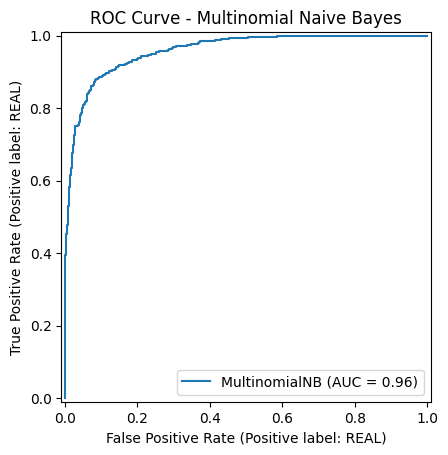

In [153]:
# Probability Prediction
y_prob_nb = best_nb.predict_proba(X_test_tfidf)[:,1]

# ROC-AUC Score
print("ROC-AUC Score:",
      roc_auc_score(y_test=="REAL", y_prob_nb))

# Plot ROC Curve
RocCurveDisplay.from_estimator(best_nb,
                               X_test_tfidf,
                               y_test)

plt.title("ROC Curve - Multinomial Naive Bayes")
plt.show()

Decision Tree


In [154]:
# Prediction
y_pred_dt = best_dt.predict(X_test_tfidf)

# Accuracy
print("Accuracy :", accuracy_score(y_test, y_pred_dt))

# Precision
print("Precision :", precision_score(y_test, y_pred_dt, pos_label="REAL"))

# Recall
print("Recall :", recall_score(y_test, y_pred_dt, pos_label="REAL"))

# F1 Score
print("F1 Score :", f1_score(y_test, y_pred_dt, pos_label="REAL"))

# Confusion Matrix
print("Confusion Matrix")
print(confusion_matrix(y_test, y_pred_dt))

# Classification Report
print("Classification Report")
print(classification_report(y_test, y_pred_dt))

Accuracy : 0.7900158478605388
Precision : 0.8133561643835616
Recall : 0.7527733755942948
F1 Score : 0.7818930041152263
Confusion Matrix
[[522 109]
 [156 475]]
Classification Report
              precision    recall  f1-score   support

        FAKE       0.77      0.83      0.80       631
        REAL       0.81      0.75      0.78       631

    accuracy                           0.79      1262
   macro avg       0.79      0.79      0.79      1262
weighted avg       0.79      0.79      0.79      1262



ROC-AUC Score: 0.7791634539796716


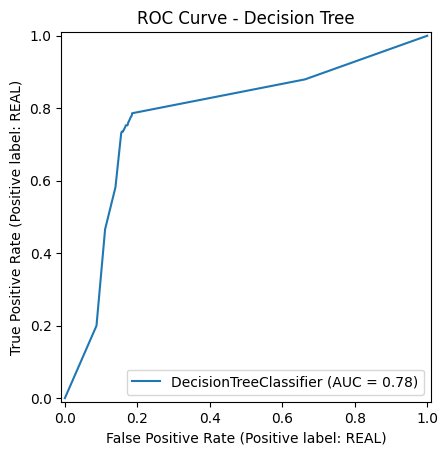

In [156]:
# Probability Prediction
y_prob_dt = best_dt.predict_proba(X_test_tfidf)[:,1]

# ROC-AUC Score
print("ROC-AUC Score:",
      roc_auc_score(y_test=="REAL", y_prob_dt))

# Plot ROC Curve
RocCurveDisplay.from_estimator(best_dt,
                               X_test_tfidf,
                               y_test)

plt.title("ROC Curve - Decision Tree")
plt.show()

In [157]:
comparison = {
    "Model": [],
    "Accuracy": [],
    "Precision": [],
    "Recall": [],
    "F1 Score": [],
    "ROC-AUC": []
}

# Naive Bayes
comparison["Model"].append("Multinomial Naive Bayes")
comparison["Accuracy"].append(accuracy_score(y_test, y_pred_nb))
comparison["Precision"].append(precision_score(y_test, y_pred_nb, pos_label="REAL"))
comparison["Recall"].append(recall_score(y_test, y_pred_nb, pos_label="REAL"))
comparison["F1 Score"].append(f1_score(y_test, y_pred_nb, pos_label="REAL"))
comparison["ROC-AUC"].append(roc_auc_score(y_test=="REAL", y_prob_nb))

# Decision Tree
comparison["Model"].append("Decision Tree")
comparison["Accuracy"].append(accuracy_score(y_test, y_pred_dt))
comparison["Precision"].append(precision_score(y_test, y_pred_dt, pos_label="REAL"))
comparison["Recall"].append(recall_score(y_test, y_pred_dt, pos_label="REAL"))
comparison["F1 Score"].append(f1_score(y_test, y_pred_dt, pos_label="REAL"))
comparison["ROC-AUC"].append(roc_auc_score(y_test=="REAL", y_prob_dt))

import pandas as pd

results = pd.DataFrame(comparison)

display(results)

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Multinomial Naive Bayes,0.876387,0.846715,0.919176,0.881459,0.958610
1,Decision Tree,0.790016,0.813356,0.752773,0.781893,0.779163


# **Step 10 : Best Model Selection**

In [158]:
import pandas as pd

# Create comparison table
comparison = pd.DataFrame({
    "Model": ["Multinomial Naive Bayes", "Decision Tree"],
    "Accuracy": [
        accuracy_score(y_test, y_pred_nb),
        accuracy_score(y_test, y_pred_dt)
    ],
    "Precision": [
        precision_score(y_test, y_pred_nb, pos_label="REAL"),
        precision_score(y_test, y_pred_dt, pos_label="REAL")
    ],
    "Recall": [
        recall_score(y_test, y_pred_nb, pos_label="REAL"),
        recall_score(y_test, y_pred_dt, pos_label="REAL")
    ],
    "F1 Score": [
        f1_score(y_test, y_pred_nb, pos_label="REAL"),
        f1_score(y_test, y_pred_dt, pos_label="REAL")
    ],
    "ROC-AUC": [
        roc_auc_score(y_test == "REAL", y_prob_nb),
        roc_auc_score(y_test == "REAL", y_prob_dt)
    ]
})

# Display comparison
print(comparison)

                     Model  Accuracy  Precision    Recall  F1 Score   ROC-AUC
0  Multinomial Naive Bayes  0.876387   0.846715  0.919176  0.881459  0.958610
1            Decision Tree  0.790016   0.813356  0.752773  0.781893  0.779163


In [159]:
# Select best model based on Accuracy
best_model = comparison.loc[comparison["Accuracy"].idxmax()]

print("\n========== Best Model ==========")
print("Model       :", best_model["Model"])
print("Accuracy    :", round(best_model["Accuracy"], 4))
print("Precision   :", round(best_model["Precision"], 4))
print("Recall      :", round(best_model["Recall"], 4))
print("F1 Score    :", round(best_model["F1 Score"], 4))
print("ROC-AUC     :", round(best_model["ROC-AUC"], 4))


========== Best Model ==========
Model       : Multinomial Naive Bayes
Accuracy    : 0.8764
Precision   : 0.8467
Recall      : 0.9192
F1 Score    : 0.8815
ROC-AUC     : 0.9586


In [160]:
# Select the best trained model
if best_model["Model"] == "Multinomial Naive Bayes":
    final_model = best_nb
else:
    final_model = best_dt

print(f"Final Model Selected: {best_model['Model']}")

Final Model Selected: Multinomial Naive Bayes


# **Step 11: Final Conclusion**



## Problem Statement

The rapid spread of fake news on digital platforms makes it difficult for users to identify trustworthy information. This project developed a Machine Learning-based Fake News Detection system that classifies news articles as **Fake** or **Real** using Natural Language Processing (NLP) techniques.

## Objective

The primary objective of this project is to build an accurate and reliable fake news classification model using text preprocessing, TF-IDF vectorization, and machine learning algorithms. The system aims to assist users in identifying misleading news articles and support informed decision-making.

## Dataset Summary

* **Dataset Source:** Kaggle
* **Total Records:** 6,335
* **Number of Features:** 4 (Unnamed, Title ,Text, Labels)
* **Text Column:** `text`
* **Target Variable:** `labels` (FAKE / REAL)

## Best Performing Model

After training and evaluating multiple machine learning models, **Multinomial Naive Bayes** was selected as the best-performing model.

### Algorithm Selected

* Multinomial Naive Bayes

### Performance Metrics

* **Accuracy:** 87.64%
* **Precision:** 84.67%
* **Recall:** 91.92%
* **F1-Score:** 88.15%
* **ROC-AUC Score:** 95.86%

## Key Insights

* Text preprocessing significantly improved the quality and consistency of the news articles.
* TF-IDF Vectorizer effectively transformed textual data into meaningful numerical features for classification.
* Multinomial Naive Bayes outperformed Decision Tree in terms of Accuracy, Recall, F1-Score, and ROC-AUC, making it the most suitable model for this text classification task.
* Words with higher TF-IDF scores contributed more strongly to distinguishing Fake and Real news articles, allowing the model to identify informative terms while reducing the influence of frequently occurring common words.

## Business Recommendations

* Integrate the model into news websites or social media platforms to provide automatic fake news alerts.
* Use the system as an initial screening tool to assist journalists and fact-checking organizations.
* Continuously retrain the model with newly collected news articles to improve prediction accuracy over time.
* Combine the model with manual verification processes for high-risk or sensitive news content.

## Practical Applications

* News verification systems
* Social media content moderation
* Fact-checking platforms
* Media monitoring and analysis
* Educational tools for improving media literacy

## Future Scope

The performance of the Fake News Detection system can be further improved by:

* Collecting larger and more diverse news datasets.
* Applying advanced text preprocessing and feature engineering techniques.
* Using Word Embedding techniques such as **Word2Vec** and **GloVe**.
* Implementing Transformer-based models such as **BERT** and **RoBERTa** for improved contextual understanding.
* Developing Deep Learning models using **LSTM** and **GRU** architectures.
* Applying Ensemble Learning methods to further improve classification accuracy and robustness.


# **Step 12: Model Saving**



In [161]:
import joblib

# Save the trained model
joblib.dump(best_nb, "fake_news_model.pkl")


print("Model saved successfully!")

Model saved successfully!


In [162]:
import joblib

# Save the TF-IDF Vectorizer
joblib.dump(tfidf_vectorizer, "tfidf_vectorizer.pkl")

print("TF-IDF Vectorizer saved successfully!")

TF-IDF Vectorizer saved successfully!


In [163]:
import os

print(os.listdir())

['.config', 'tfidf_vectorizer.pkl', 'fake_news_model.pkl', 'fake_or_real_news.csv', 'sample_data']


# **Step 13: Using the Model in UI**


In [164]:
!pip install streamlit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 49.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.4/11.4 MB 62.6 MB/s eta 0:00:00


# **Step 14: Model Loading**


In [166]:
import streamlit as st
import joblib

model = joblib.load("fake_news_model.pkl")


In [167]:
model

MultinomialNB(alpha=0.1)

In [168]:
import joblib

vectorizer = joblib.load("tfidf_vectorizer.pkl")

print("Vectorizer loaded successfully!")

Vectorizer loaded successfully!


In [169]:
# Example news article
news = """
Scientists have discovered a new planet that may support life.
"""

# Convert text into TF-IDF features
news_vector = vectorizer.transform([news])

# Make prediction
prediction = model.predict(news_vector)

print("Prediction:", prediction[0])

Prediction: FAKE


In [177]:
news = """
WASHINGTON (Reuters) - The U.S. Senate approved a government spending bill
on Thursday to avoid a partial government shutdown after lawmakers from both
parties reached an agreement on federal funding. The legislation will now be
sent to the President for final approval. Congressional leaders said the bill
includes funding for infrastructure, healthcare, and national security
programs while maintaining existing government operations.
"""

# Convert text into TF-IDF features
news_vector = vectorizer.transform([news])

# Predict
prediction = model.predict(news_vector)

# Predict probability
probability = model.predict_proba(news_vector)

print("Prediction:", prediction[0])
print(f"Confidence: {max(probability[0]) * 100:.2f}%")

Prediction: REAL
Confidence: 89.59%
